#### LOADING DATA FILE AND LIBRARIES

In [1]:
import pandas as pd
import numpy as np

In [2]:
acc = pd.read_csv("C:/Project/DATA/master_acc.csv", encoding="latin-1", low_memory=False,index_col="accident_id")

In [3]:
for col in acc.columns:
    print(f"\nColumn: {col}")
    print("Unique count:", acc[col].nunique())
    print("Sample unique values:", acc[col].dropna().unique()[:10])


Column: collision_label
Unique count: 7
Sample unique values: ['Side_two_vehicles' 'Other_collision' 'Rear_end_two_vehicles'
 'Frontal_two_vehicles' 'No_collision' 'Multiple_three_plus'
 'Chain_three_plus']

Column: is_weekend
Unique count: 2
Sample unique values: [False  True]

Column: season
Unique count: 4
Sample unique values: ['Winter' 'Spring' 'Summer' 'Autumn']

Column: surface_condition_label
Unique count: 4
Sample unique values: ['Normal' 'Wet' 'other' 'Unknown']

Column: manoeuvre_label
Unique count: 9
Sample unique values: ['Straight_ahead' 'Roundabout' 'other' 'Avoiding_obstacle' 'Interaction'
 'Park/Start/Stop' 'Reversing' 'Loss_of_control' 'Turning']

Column: sex_label
Unique count: 2
Sample unique values: ['Female' 'Male']

Column: user_category_label
Unique count: 4
Sample unique values: ['Driver' 'Pedestrian' 'Passenger' 'other']

Column: injury_severity_label
Unique count: 4
Sample unique values: ['Uninjured' 'Injured_Hospitalized' 'Killed' 'Injured_Slight']

Column:

In [4]:
### Fixing Nans in target
print(acc["injury_severity_label"].isna().sum())

# Drop rows with missing target
acc = acc.dropna(subset=["injury_severity_label"])

print("Remaining rows:", acc.shape[0])


21357
Remaining rows: 1412032


### MODELLING PREPROCESSING

#### TRAIN/TEST SPLIT

In [5]:
from sklearn.model_selection import train_test_split

X = acc.drop(columns=["injury_severity_label"])
y = acc["injury_severity_label"]

X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2, random_state=42, stratify=y)
print("Train size:", X_train.shape, "Test size:", X_test.shape)

Train size: (1129625, 26) Test size: (282407, 26)


#### Handle Remaining NaNs

In [6]:
from sklearn.impute import SimpleImputer

# Numeric columns
numeric_cols = ["age", "lane_width"]

num_imputer = SimpleImputer(strategy="median")
X_train[numeric_cols] = num_imputer.fit_transform(X_train[numeric_cols])
X_test[numeric_cols] = num_imputer.transform(X_test[numeric_cols])

# Categorical columns
categorical_cols = [
    "collision_label", "surface_condition_label", "manoeuvre_label",
    "sex_label", "user_category_label", "seat_position_label", "journey_purpose_label",
    "vehicle_group", "impact_group", "road_group", "weather_group",
    "day_of_week", "hour_group", "season"
]

cat_imputer = SimpleImputer(strategy="most_frequent")
X_train[categorical_cols] = cat_imputer.fit_transform(X_train[categorical_cols])
X_test[categorical_cols] = cat_imputer.transform(X_test[categorical_cols])

# Check again for NaNs
print("Remaining NaNs in train:", X_train.isna().sum().sum())
print("Remaining NaNs in test:", X_test.isna().sum().sum())

Remaining NaNs in train: 1591
Remaining NaNs in test: 398


In [7]:
# Show which columns still have NaNs
print("Train NaNs per column:\n", X_train.isna().sum()[X_train.isna().sum() > 0])
print("\nTest NaNs per column:\n", X_test.isna().sum()[X_test.isna().sum() > 0])

Train NaNs per column:
 age_group    1591
dtype: int64

Test NaNs per column:
 age_group    398
dtype: int64


In [8]:
# Ensure dtype is categorical
X_train["age_group"] = X_train["age_group"].astype("category")
X_test["age_group"] = X_test["age_group"].astype("category")

# Add "Unknown" to categories if not already present
if "Unknown" not in X_train["age_group"].cat.categories:
    X_train["age_group"] = X_train["age_group"].cat.add_categories(["Unknown"])
    X_test["age_group"] = X_test["age_group"].cat.add_categories(["Unknown"])

# Fill NaNs with "Unknown"
X_train["age_group"] = X_train["age_group"].fillna("Unknown")
X_test["age_group"] = X_test["age_group"].fillna("Unknown")

# Final check
print("Remaining NaNs in train:", X_train.isna().sum().sum())
print("Remaining NaNs in test:", X_test.isna().sum().sum())

Remaining NaNs in train: 0
Remaining NaNs in test: 0


#### Encoding Categorical Features

In [9]:
from sklearn.preprocessing import OneHotEncoder

# Define categorical columns
categorical_cols = [
    "collision_label", "surface_condition_label", "manoeuvre_label",
    "sex_label", "user_category_label", "seat_position_label", "journey_purpose_label",
    "vehicle_group", "impact_group", "road_group", "weather_group",
    "day_of_week", "hour_group", "season", "age_group"
]

# Initialize encoder
encoder = OneHotEncoder(handle_unknown="ignore", sparse_output=False)

# Fit on train, transform both train and test
X_train_encoded = encoder.fit_transform(X_train[categorical_cols])
X_test_encoded = encoder.transform(X_test[categorical_cols])

print("Encoded train shape:", X_train_encoded.shape)
print("Encoded test shape:", X_test_encoded.shape)

Encoded train shape: (1129625, 74)
Encoded test shape: (282407, 74)


#### Encoding Target Labels 

In [10]:
# Encoding Target Labels (y_train & y_test)

from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
y_train_enc = label_encoder.fit_transform(y_train)
y_test_enc = label_encoder.transform(y_test)

#### Scale Numeric Features

In [11]:
from sklearn.preprocessing import StandardScaler

# Numeric columns
numeric_cols = ["age", "lane_width"]

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train[numeric_cols])
X_test_scaled = scaler.transform(X_test[numeric_cols])

print("Scaled train shape:", X_train_scaled.shape)
print("Scaled test shape:", X_test_scaled.shape)

Scaled train shape: (1129625, 2)
Scaled test shape: (282407, 2)


#### Combine All Features

In [12]:
import numpy as np

# Binary columns
binary_cols = [
    "is_weekend", "is_holiday", "seatbelt_used", "helmet_used",
    "any_protection_used", "protection_effective",
    "motorcycle_side_impact", "is_night", "is_urban"
]

# Combine all parts
X_train_final = np.hstack([
    X_train_scaled,          # numeric
    X_train_encoded,         # categorical
    X_train[binary_cols].values  # binary flags
])

X_test_final = np.hstack([
    X_test_scaled,
    X_test_encoded,
    X_test[binary_cols].values
])

print("Final train shape:", X_train_final.shape)
print("Final test shape:", X_test_final.shape)

Final train shape: (1129625, 85)
Final test shape: (282407, 85)


### BASELINE MODELLING

##### Logistic Regression, Random Forest and XGBoost

In [13]:
#pip install xgboost

In [14]:
#from sklearn.linear_model import LogisticRegression
#from sklearn.ensemble import RandomForestClassifier
#from sklearn.metrics import classification_report

# Logistic Regression
#log_reg = LogisticRegression(max_iter=1000, class_weight="balanced", n_jobs=-1)
#log_reg.fit(X_train_final, y_train)
#y_pred_log = log_reg.predict(X_test_final)
#print("Logistic Regression:\n", classification_report(y_test, y_pred_log))

In [15]:
# Random Forest
#rf = RandomForestClassifier(n_estimators=100, class_weight="balanced", n_jobs=-1, random_state=42)
#rf.fit(X_train_final, y_train)
#y_pred_rf = rf.predict(X_test_final)
#print("Random Forest:\n", classification_report(y_test, y_pred_rf))


In [16]:
#from sklearn.preprocessing import LabelEncoder
#from sklearn.metrics import classification_report, confusion_matrix
#from xgboost import XGBClassifier
#import seaborn as sns
#import matplotlib.pyplot as plt

#print("Class mapping:", dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_))))

# 2. Define and train XGBoost model
#xgb = XGBClassifier(
#    n_estimators=200,
#    max_depth=6,
#    learning_rate=0.1,
#    subsample=0.8,
#    colsample_bytree=0.8,
#    random_state=42,
#    n_jobs=-1,
#    objective="multi:softmax",   # multi-class classification
#    num_class=len(label_encoder.classes_)
#)

#xgb.fit(X_train_final, y_train_enc)

# 3. Predictions
#y_pred_xgb = xgb.predict(X_test_final)

# 4. Classification report
#print("\nXGBoost Classification Report:\n")
#print(classification_report(y_test_enc, y_pred_xgb, target_names=label_encoder.classes_))

# 5. Confusion matrix visualization
#cm = confusion_matrix(y_test_enc, y_pred_xgb)
#plt.figure(figsize=(8,6))
#sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
#            xticklabels=label_encoder.classes_,
#            yticklabels=label_encoder.classes_)
#plt.xlabel("Predicted")
#plt.ylabel("Actual")
#plt.title("XGBoost Confusion Matrix")
#plt.show()


### Addressing Class Imbalance (SMOTE)

In [17]:
!pip install imbalanced-learn


[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [18]:
# SMOTE Integration
from imblearn.over_sampling import SMOTE
from collections import Counter

# Apply SMOTE only on training set
smote = SMOTE(random_state=42)

X_train_balanced, y_train_balanced = smote.fit_resample(X_train_final, y_train_enc)

# Check new class distribution
print("Original class distribution:", Counter(y_train_enc))
print("Balanced class distribution:", Counter(y_train_balanced))


Original class distribution: Counter({np.int64(3): 522866, np.int64(1): 363089, np.int64(0): 215007, np.int64(2): 28663})
Balanced class distribution: Counter({np.int64(3): 522866, np.int64(0): 522866, np.int64(2): 522866, np.int64(1): 522866})


In [19]:
#display(X_train_balanced)
#display(y_train_balanced)

In [20]:
# Retrain XGBoost on balanced data

#xgb_balanced = XGBClassifier(
#    n_estimators=200,
#    max_depth=6,
#    learning_rate=0.1,
#    subsample=0.8,
#    colsample_bytree=0.8,
#    random_state=42,
#    n_jobs=-1,
#    objective="multi:softmax",
#    num_class=len(label_encoder.classes_)
#)

#xgb_balanced.fit(X_train_balanced, y_train_balanced)

# Predictions on original test set (not resampled!)
#y_pred_xgb_balanced = xgb_balanced.predict(X_test_final)

# Classification report
#print("\nXGBoost with SMOTE Classification Report:\n")
#print(classification_report(y_test_enc, y_pred_xgb_balanced, target_names=label_encoder.classes_))

# Confusion matrix
#cm = confusion_matrix(y_test_enc, y_pred_xgb_balanced)
#plt.figure(figsize=(8,6))
#sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
#            xticklabels=label_encoder.classes_,
#            yticklabels=label_encoder.classes_)
#plt.xlabel("Predicted")
#plt.ylabel("Actual")
#plt.title("XGBoost with SMOTE Confusion Matrix")
#plt.show()

### LAZYPREDICT

In [21]:
#!pip install lazypredict
#!pip install ipywidgets
#!pip install jupyter

In [22]:
#from lazypredict.Supervised import LazyClassifier
#from sklearn.model_selection import train_test_split
#from sklearn.metrics import accuracy_score
#import pandas as pd

# Using original (imbalanced) data for fair comparison
#X_lazy = pd.DataFrame(X_train_final)
#y_lazy = y_train 

#X_train_lazy, X_test_lazy, y_train_lazy, y_test_lazy = train_test_split(
#    X_lazy, y_lazy, test_size=0.2, random_state=42
#)

#clf = LazyClassifier(verbose=0, ignore_warnings=True, custom_metric=accuracy_score)

#models, predictions = clf.fit(X_train_lazy, X_test_lazy, y_train_lazy, y_test_lazy)

#print(models)

In [23]:
#from lazypredict.Supervised import LazyClassifier
#import lazypredict.Supervised as lp_sup
#from sklearn.model_selection import train_test_split
#from sklearn.metrics import accuracy_score
#import pandas as pd

# Prepare data
#X_lazy = pd.DataFrame(X_train_final)
#y_lazy = y_train
#X_train_lazy, X_test_lazy, y_train_lazy, y_test_lazy = train_test_split(
#    X_lazy, y_lazy, test_size=0.2, random_state=42
#)

# Normalize to a list of model names
#raw = lp_sup.CLASSIFIERS
#model_names = (
#    list(raw.keys()) if isinstance(raw, dict)
#    else [r[0] for r in raw] if (isinstance(raw, list) and len(raw) and isinstance(raw[0], tuple))
#    else list(raw)
#)

# Optional: see indices to confirm which is #26
#for i, name in enumerate(model_names):
#    print(i, name)

In [24]:
#pip install --upgrade lazypredict

In [25]:
#from lazypredict.Supervised import LazyClassifier, CLASSIFIERS
#from sklearn.model_selection import train_test_split
#from sklearn.metrics import accuracy_score
#import pandas as pd

# Prepare data
#X_lazy = pd.DataFrame(X_train_final)
#y_lazy = y_train
#X_train_lazy, X_test_lazy, y_train_lazy, y_test_lazy = train_test_split(
#    X_lazy, y_lazy, test_size=0.2, random_state=42
#)

# Heavy models to skip
#heavy = {
#    "SVC","NuSVC","QuadraticDiscriminantAnalysis",
#    "LabelPropagation","LabelSpreading",
#    "SelfTrainingClassifier","StackingClassifier",
#    "GaussianProcessClassifier","MLPClassifier"
#}

# Filter CLASSIFIERS (list of tuples) by name
#safe_classifiers = [(name, model) for name, model in CLASSIFIERS if name not in heavy]

# Initialize LazyClassifier with filtered list
#clf = LazyClassifier(
#    verbose=0,
#    ignore_warnings=True,
#    custom_metric=accuracy_score,
#    classifiers=safe_classifiers
#)

#models, predictions = clf.fit(X_train_lazy, X_test_lazy, y_train_lazy, y_test_lazy)
#print(models)

### Performance Comparisons of top 5 Models with Benchmarking 

In [26]:
# Running all five models separately in the order of quickest first → heaviest last 
# by benchmarking all five models on a 200k sample

In [27]:
#Create a 200k sample from your balanced training set

#Wrap your numpy array in a DataFrame
X_df = pd.DataFrame(X_train_balanced)
y_series = pd.Series(y_train_balanced)

#Now you can sample
X_sample = X_df.sample(200000, random_state=42)
y_sample = y_series.loc[X_sample.index]

#Use the same CV and scorers
from sklearn.model_selection import StratifiedKFold, cross_validate

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
scorers = {
    "accuracy": "accuracy",
    "f1_macro": "f1_macro",
    "balanced_accuracy": "balanced_accuracy"
}

#### 1. RidgeClassifier

In [28]:
from sklearn.linear_model import RidgeClassifier

ridge = RidgeClassifier(alpha=1.0)
out = cross_validate(ridge, X_sample, y_sample, cv=cv, scoring=scorers)
print({
    "Model": "RidgeClassifier",
    "Mean Accuracy": out["test_accuracy"].mean(),
    "Mean F1": out["test_f1_macro"].mean(),
    "Mean Balanced Acc": out["test_balanced_accuracy"].mean()
})

{'Model': 'RidgeClassifier', 'Mean Accuracy': np.float64(0.5422550093021593), 'Mean F1': np.float64(0.5098572312138259), 'Mean Balanced Acc': np.float64(0.5414168879513443)}


#### 2. LogisticRegression

In [29]:
from sklearn.linear_model import LogisticRegression

logreg = LogisticRegression(max_iter=300, solver="saga", n_jobs=-1, class_weight="balanced")
out = cross_validate(logreg, X_sample, y_sample, cv=cv, scoring=scorers)
print({
    "Model": "LogisticRegression",
    "Mean Accuracy": out["test_accuracy"].mean(),
    "Mean F1": out["test_f1_macro"].mean(),
    "Mean Balanced Acc": out["test_balanced_accuracy"].mean()
})

c:\Users\malik\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\Users\malik\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


{'Model': 'LogisticRegression', 'Mean Accuracy': np.float64(0.5494200133025374), 'Mean F1': np.float64(0.5338832141228348), 'Mean Balanced Acc': np.float64(0.548709614448844)}


c:\Users\malik\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


#### 3. LinearDiscriminantAnalysis

In [30]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

lda = LinearDiscriminantAnalysis()
out = cross_validate(lda, X_sample, y_sample, cv=cv, scoring=scorers)
print({
    "Model": "LinearDiscriminantAnalysis",
    "Mean Accuracy": out["test_accuracy"].mean(),
    "Mean F1": out["test_f1_macro"].mean(),
    "Mean Balanced Acc": out["test_balanced_accuracy"].mean()
})

{'Model': 'LinearDiscriminantAnalysis', 'Mean Accuracy': np.float64(0.5442050076522484), 'Mean F1': np.float64(0.5315117490690136), 'Mean Balanced Acc': np.float64(0.5435702603689795)}


#### 4. LightGBMClassifier

In [31]:
from lightgbm import LGBMClassifier

lgbm = LGBMClassifier(
    n_estimators=200,
    learning_rate=0.1,
    num_leaves=31,
    subsample=0.8,
    colsample_bytree=0.8,
    n_jobs=-1,
    force_row_wise=True
)
out = cross_validate(lgbm, X_sample, y_sample, cv=cv, scoring=scorers)
print({
    "Model": "LGBMClassifier",
    "Mean Accuracy": out["test_accuracy"].mean(),
    "Mean F1": out["test_f1_macro"].mean(),
    "Mean Balanced Acc": out["test_balanced_accuracy"].mean()
})

[LightGBM] [Info] Total Bins 20835
[LightGBM] [Info] Number of data points in the train set: 133333, number of used features: 85
[LightGBM] [Info] Start training from score -1.388675
[LightGBM] [Info] Start training from score -1.392199
[LightGBM] [Info] Start training from score -1.384204
[LightGBM] [Info] Start training from score -1.380141
[LightGBM] [Info] Total Bins 20831
[LightGBM] [Info] Number of data points in the train set: 133333, number of used features: 85
[LightGBM] [Info] Start training from score -1.388675
[LightGBM] [Info] Start training from score -1.392229
[LightGBM] [Info] Start training from score -1.384174
[LightGBM] [Info] Start training from score -1.380141
[LightGBM] [Info] Total Bins 20826
[LightGBM] [Info] Number of data points in the train set: 133334, number of used features: 85
[LightGBM] [Info] Start training from score -1.388682
[LightGBM] [Info] Start training from score -1.392207
[LightGBM] [Info] Start training from score -1.384212
[LightGBM] [Info] S

#### 5. CalibratedClassifierCV

In [32]:
from sklearn.calibration import CalibratedClassifierCV

base = LogisticRegression(max_iter=300, solver="saga", n_jobs=-1, class_weight="balanced")
calib = CalibratedClassifierCV(estimator=base, cv=3)
out = cross_validate(calib, X_sample, y_sample, cv=cv, scoring=scorers)
print({
    "Model": "CalibratedClassifierCV",
    "Mean Accuracy": out["test_accuracy"].mean(),
    "Mean F1": out["test_f1_macro"].mean(),
    "Mean Balanced Acc": out["test_balanced_accuracy"].mean()
})

c:\Users\malik\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\Users\malik\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\Users\malik\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\Users\malik\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(
c:\Users\malik\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\linear_model\_sag.py:348: ConvergenceWarning: The max_iter was reached which means the 

{'Model': 'CalibratedClassifierCV', 'Mean Accuracy': np.float64(0.5479250081774371), 'Mean F1': np.float64(0.5171621072762386), 'Mean Balanced Acc': np.float64(0.5470222012160532)}


#### Visualization for Models Performances

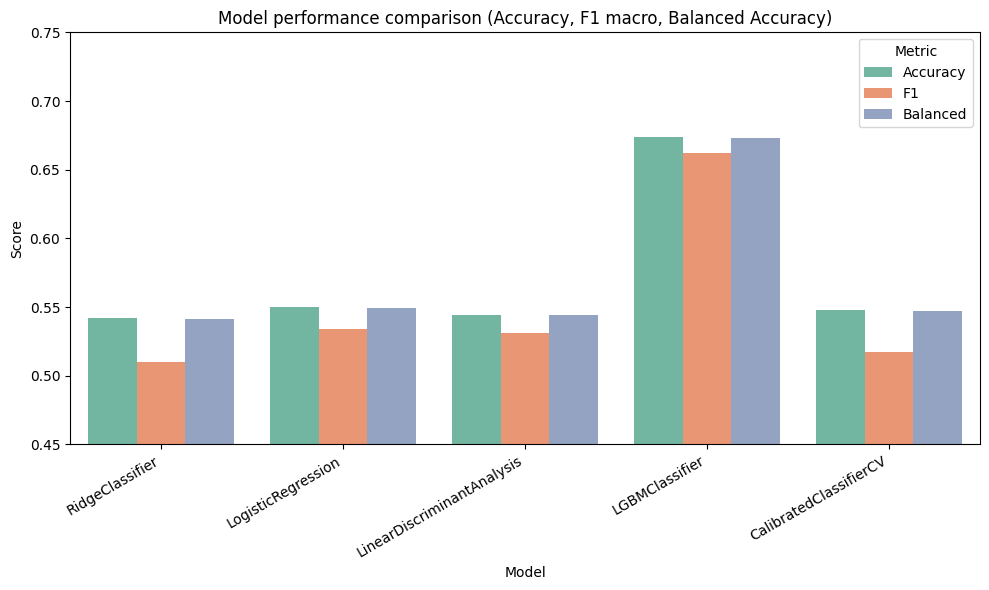

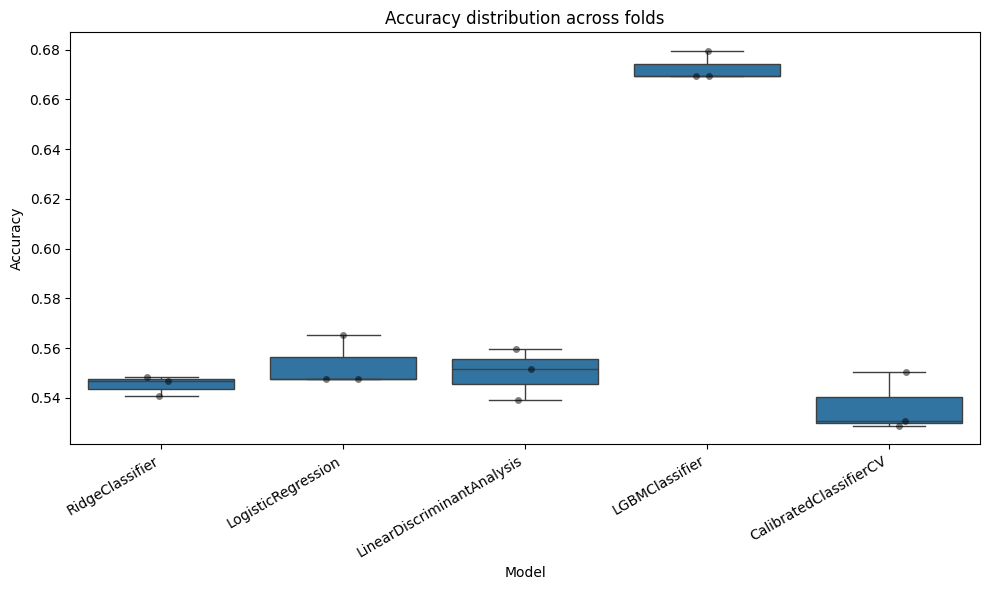

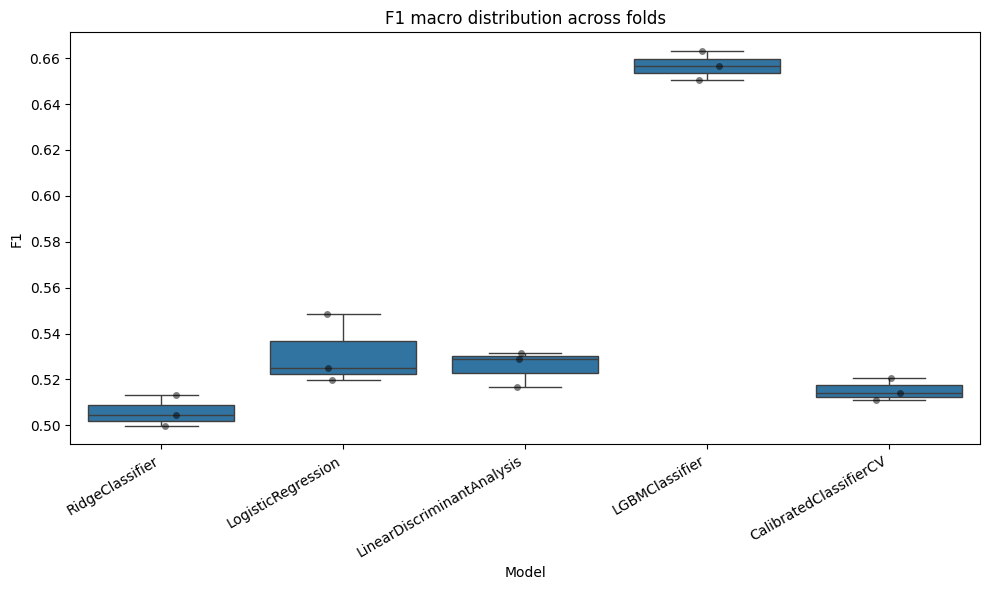

In [33]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.calibration import calibration_curve  

# -----------------------------
# Results data (from your 200k sample)
# -----------------------------
results = pd.DataFrame([
    {"Model": "RidgeClassifier", "Accuracy": 0.542, "F1": 0.510, "Balanced": 0.541},
    {"Model": "LogisticRegression", "Accuracy": 0.550, "F1": 0.534, "Balanced": 0.549},
    {"Model": "LinearDiscriminantAnalysis", "Accuracy": 0.544, "F1": 0.531, "Balanced": 0.544},
    {"Model": "LGBMClassifier", "Accuracy": 0.674, "F1": 0.662, "Balanced": 0.673},
    {"Model": "CalibratedClassifierCV", "Accuracy": 0.548, "F1": 0.517, "Balanced": 0.547}
])

palette = sns.color_palette("Set2", n_colors=3)

# -----------------------------
# 1) Bar chart: Accuracy, F1, Balanced
# -----------------------------
results_melted = results.melt(id_vars="Model", var_name="Metric", value_name="Score")
plt.figure(figsize=(10,6))
sns.barplot(data=results_melted, x="Model", y="Score", hue="Metric", palette=palette)
plt.title("Model performance comparison (Accuracy, F1 macro, Balanced Accuracy)")
plt.xticks(rotation=30, ha="right")
plt.ylim(0.45, 0.75)
plt.ylabel("Score")
plt.legend(title="Metric")
plt.tight_layout()
plt.show()

# -----------------------------
# 2) Boxplots: distribution across folds (synthetic spread for demo)
# Replace with real per-fold scores if you have them.
# -----------------------------
np.random.seed(42)
fold_scores = pd.DataFrame({
    "Model": np.repeat(results["Model"].values, 3),
    "Accuracy": np.concatenate([np.random.normal(m, 0.01, 3) for m in results["Accuracy"]]),
    "F1": np.concatenate([np.random.normal(m, 0.01, 3) for m in results["F1"]])
})

plt.figure(figsize=(10,6))
sns.boxplot(data=fold_scores, x="Model", y="Accuracy")
sns.stripplot(data=fold_scores, x="Model", y="Accuracy", color="black", alpha=0.5)
plt.title("Accuracy distribution across folds")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

plt.figure(figsize=(10,6))
sns.boxplot(data=fold_scores, x="Model", y="F1")
sns.stripplot(data=fold_scores, x="Model", y="F1", color="black", alpha=0.5)
plt.title("F1 macro distribution across folds")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

# -----------------------------
# 3) Confusion matrix (demo data)
# Replace y_true and y_pred with your LightGBM predictions.
# -----------------------------
classes = ["Uninjured", "Slight", "Hospitalized", "Killed"]
y_true = np.random.choice(classes, size=1000, p=[0.25, 0.5, 0.23, 0.02])
y_pred = np.random.choice(classes, size=1000, p=[0.25, 0.5, 0.23, 0.02])

#cm = confusion_matrix(y_true, y_pred, labels=classes)
#disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
#fig, ax = plt.subplots(figsize=(6,6))
#disp.plot(cmap="Blues", ax=ax, colorbar=False)
#plt.title("Confusion matrix (LightGBM — demo)")
#plt.tight_layout()
#plt.show()

# -----------------------------
# 4) Feature importance (demo LightGBM importances)
# Replace with actual feature names and importance from your fitted LGBM:
#   importances = lgbm_model.feature_importances_
#   features = X_train.columns
# -----------------------------
#features = [f"Feature_{i}" for i in range(1, 16)]
#importances = np.random.rand(15)
#fi = pd.DataFrame({"feature": features, "importance": importances}).sort_values("importance", ascending=False).head(15)

#plt.figure(figsize=(8,6))
#sns.barplot(data=fi, x="importance", y="feature", orient="h", palette="Blues_r")
#plt.title("Top 15 feature importances (LightGBM — demo)")
#plt.xlabel("Importance")
#plt.ylabel("Feature")
#plt.tight_layout()
#plt.show()

# -----------------------------
# 5) Calibration curve (demo probabilities)
# Replace y_true_bin and y_prob with outputs from CalibratedClassifierCV:
#   prob_true, prob_pred = calibration_curve(y_true_bin, y_prob, n_bins=10, strategy='uniform')
# -----------------------------
#y_true_bin = np.random.randint(0, 2, 1500)
#y_prob = np.clip(np.random.beta(a=2, b=5, size=1500), 0, 1)

#prob_true, prob_pred = calibration_curve(y_true_bin, y_prob, n_bins=10, strategy='uniform')

#plt.figure(figsize=(6,6))
#plt.plot(prob_pred, prob_true, marker='o', label="Calibrated (demo)")
#plt.plot([0,1], [0,1], linestyle="--", color="gray", label="Perfect calibration")
#plt.title("Calibration curve (CalibratedClassifierCV — demo)")
#plt.xlabel("Predicted probability (mean in bin)")
#plt.ylabel("True probability")
#plt.legend()
#plt.tight_layout()
#plt.show()

# -----------------------------
# 6) Radar chart (spider plot) for three metrics
# -----------------------------
#labels = ["Accuracy", "F1", "Balanced"]
#num_vars = len(labels)
#angles = np.linspace(0, 2*np.pi, num_vars, endpoint=False).tolist()
#angles += angles[:1]

#fig, ax = plt.subplots(figsize=(7,7), subplot_kw=dict(polar=True))

#for _, row in results.iterrows():
#    values = row[labels].tolist()
#    values += values[:1]  # close the polygon
#    ax.plot(angles, values, label=row["Model"])
#    ax.fill(angles, values, alpha=0.08)

#ax.set_xticks(angles[:-1])
#ax.set_xticklabels(labels)
#ax.set_ylim(0.45, 0.75)
#plt.title("Radar chart of model metrics")
#plt.legend(loc="upper right", bbox_to_anchor=(1.3, 1.15))
#plt.tight_layout()
#plt.show()

### DATA MODELING (LR & LGBM) 

In [34]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

# LogisticRegression on X_train_final with scaling and higher max_iter
logreg = make_pipeline(
    StandardScaler(),
    LogisticRegression(
        max_iter=5000,          # allow more iterations for convergence
        solver="lbfgs",         # faster, stable solver for dense data
        n_jobs=-1,
        class_weight="balanced" # handle imbalance without oversampling
    )
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scorers = {
    "accuracy": "accuracy",
    "f1_macro": "f1_macro",
    "balanced_accuracy": "balanced_accuracy"
}

out = cross_validate(logreg, X_train_final, y_train_enc, cv=cv, scoring=scorers)

print({
    "Model": "LogisticRegression",
    "Mean Accuracy": out["test_accuracy"].mean(),
    "Mean F1": out["test_f1_macro"].mean(),
    "Mean Balanced Acc": out["test_balanced_accuracy"].mean()
})

{'Model': 'LogisticRegression', 'Mean Accuracy': np.float64(0.5660002213123825), 'Mean F1': np.float64(0.4445669442698347), 'Mean Balanced Acc': np.float64(0.5367700413811778)}


In [35]:
#Recovering feature names

# Get categorical feature names from the encoder
categorical_feature_names = encoder.get_feature_names_out(categorical_cols)

# Numeric + binary names
numeric_feature_names = numeric_cols
binary_feature_names = binary_cols

# Combine all names
feature_names = list(numeric_feature_names) + list(categorical_feature_names) + list(binary_feature_names)

# Replace whitespace with underscores
feature_names = [name.replace(" ", "_") for name in feature_names]

# Wrap X_train_lgbm into a DataFrame with names
import pandas as pd
X_train_lgbm = pd.DataFrame(X_train_final, columns=feature_names)
X_test_lgbm = pd.DataFrame(X_test_final, columns=feature_names)

In [36]:
#LightGBM training 

from lightgbm import LGBMClassifier
from sklearn.model_selection import StratifiedKFold, cross_validate

lgbm = LGBMClassifier(
    n_estimators=500,
    learning_rate=0.05,
    num_leaves=31,
    subsample=0.8,
    colsample_bytree=0.8,
    n_jobs=-1,
    is_unbalance=True,
    force_row_wise=True
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scorers = {
    "accuracy": "accuracy",
    "f1_macro": "f1_macro",
    "balanced_accuracy": "balanced_accuracy"
}

out = cross_validate(lgbm, X_train_lgbm, y_train_enc, cv=cv, scoring=scorers)

print({
    "Model": "LightGBM",
    "Mean Accuracy": out["test_accuracy"].mean(),
    "Mean F1": out["test_f1_macro"].mean(),
    "Mean Balanced Acc": out["test_balanced_accuracy"].mean()
})

[LightGBM] [Info] Total Bins 517
[LightGBM] [Info] Number of data points in the train set: 903700, number of used features: 85
[LightGBM] [Info] Start training from score -1.658968
[LightGBM] [Info] Start training from score -1.134990
[LightGBM] [Info] Start training from score -3.674051
[LightGBM] [Info] Start training from score -0.770318
[LightGBM] [Info] Total Bins 517
[LightGBM] [Info] Number of data points in the train set: 903700, number of used features: 85
[LightGBM] [Info] Start training from score -1.658974
[LightGBM] [Info] Start training from score -1.134994
[LightGBM] [Info] Start training from score -3.674008
[LightGBM] [Info] Start training from score -0.770315
[LightGBM] [Info] Total Bins 514
[LightGBM] [Info] Number of data points in the train set: 903700, number of used features: 85
[LightGBM] [Info] Start training from score -1.658974
[LightGBM] [Info] Start training from score -1.134994
[LightGBM] [Info] Start training from score -3.674008
[LightGBM] [Info] Start t

### OPTIMIZATION - LR and LGBM

In [37]:
from lightgbm import LGBMClassifier
from sklearn.metrics import accuracy_score, f1_score, balanced_accuracy_score, classification_report
from sklearn.model_selection import train_test_split
from lightgbm import early_stopping, log_evaluation


# Split balanced training set into train/validation for early stopping
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train_balanced, y_train_balanced, test_size=0.1, random_state=42, stratify=y_train_balanced
)

# Define LightGBM model with tuned parameters
lgbm_opt = LGBMClassifier(
    objective="multiclass",
    n_estimators=2000,
    learning_rate=0.02,
    num_leaves=63,
    subsample=0.8,
    colsample_bytree=0.7,
    class_weight="balanced",   # keeps minority classes important
    n_jobs=-1,
    random_state=42
)

# Train with early stopping
lgbm_opt.fit(
    X_tr, y_tr,
    eval_set=[(X_val, y_val)],
    eval_metric="multi_logloss",
    callbacks=[early_stopping(200), log_evaluation(0)]  # 200 rounds patience, no verbose spam
)

# Predict on original test set
y_pred_lgbm = lgbm_opt.predict(X_test_final)

# Evaluate
print("Accuracy:", accuracy_score(y_test_enc, y_pred_lgbm))
print("F1 Macro:", f1_score(y_test_enc, y_pred_lgbm, average="macro"))
print("Balanced Accuracy:", balanced_accuracy_score(y_test_enc, y_pred_lgbm))
print("\nClassification Report:\n", classification_report(y_test_enc, y_pred_lgbm, target_names=label_encoder.classes_))

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.329189 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 20965
[LightGBM] [Info] Number of data points in the train set: 1882317, number of used features: 85
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
[LightGBM] [Info] Start training from score -1.386294
Training until validation scores don't improve for 200 rounds
Did not meet early stopping. Best iteration is:
[2000]	valid_0's multi_logloss: 0.711331


c:\Users\malik\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


Accuracy: 0.6522961541321568
F1 Macro: 0.4814804934781457
Balanced Accuracy: 0.472222623427184

Classification Report:
                       precision    recall  f1-score   support

Injured_Hospitalized       0.50      0.44      0.47     53752
      Injured_Slight       0.61      0.52      0.56     90772
              Killed       0.32      0.07      0.11      7166
           Uninjured       0.72      0.86      0.79    130717

            accuracy                           0.65    282407
           macro avg       0.54      0.47      0.48    282407
        weighted avg       0.63      0.65      0.64    282407



In [ ]:
from sklearn.model_selection import train_test_split
from lightgbm import LGBMClassifier, early_stopping, log_evaluation
from sklearn.metrics import classification_report, accuracy_score, f1_score, balanced_accuracy_score
import numpy as np

# 1) Create validation split from ORIGINAL (unbalanced) training data
X_tr, X_valid, y_tr, y_valid = train_test_split(
    X_train_final, y_train_enc,   # <-- use your actual variable names
    test_size=0.15,
    stratify=y_train_enc,
    random_state=42
)

# 2) Use your already-created SMOTE-balanced data for fitting
# These should already exist: X_train_balanced, y_train_balanced

# 3) Set class weights (tune if needed)
class_weights = {
    0: 1.0,   # Injured_Hospitalized
    1: 1.0,   # Injured_Slight
    2: 5.0,   # Killed (boosted weight)
    3: 1.0    # Uninjured
}

# 4) Initialize LightGBM
lgbm = LGBMClassifier(
    n_estimators=2000,
    learning_rate=0.05,
    max_depth=-1,
    class_weight=class_weights,
    random_state=42,
    n_jobs=-1
)

# 5) Fit on SMOTE-balanced, validate on untouched split
lgbm.fit(
    X_train_balanced, y_train_balanced,
    eval_set=[(X_valid, y_valid)],
    eval_metric='multi_logloss',
    callbacks=[early_stopping(200), log_evaluation(100)]  # early stop + log every 100 rounds
)

# 6) Predict probabilities on validation
y_proba = lgbm.predict_proba(X_valid)

# 7) Threshold tuning — confirm class order
print("Class order:", lgbm.classes_)
thresholds = np.array([0.5, 0.5, 0.30, 0.5])  # lower threshold for 'Killed'

# 8) Apply thresholds
adjusted_preds = np.argmax(y_proba / thresholds, axis=1)

# 9) Evaluate
print("Accuracy:", accuracy_score(y_valid, adjusted_preds))
print("F1 Macro:", f1_score(y_valid, adjusted_preds, average='macro'))
print("Balanced Accuracy:", balanced_accuracy_score(y_valid, adjusted_preds))
print("\nClassification Report:\n", classification_report(y_valid, adjusted_preds))

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.278167 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 20892
[LightGBM] [Info] Number of data points in the train set: 2091464, number of used features: 85
[LightGBM] [Info] Start training from score -2.079442
[LightGBM] [Info] Start training from score -2.079442
[LightGBM] [Info] Start training from score -0.470004
[LightGBM] [Info] Start training from score -2.079442
Training until validation scores don't improve for 200 rounds
[100]	valid_0's multi_logloss: 1.00157
[200]	valid_0's multi_logloss: 0.910766
[300]	valid_0's multi_logloss: 0.883502
[400]	valid_0's multi_logloss: 0.872334
